In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45, Heun

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
    get_parameter_save_callback
)
from tfim_exact_z import get_ed
from schmitt_tdvp_randomized_blur import TDVPSchmittRandomizedBlur
from logger import Logger

W0312 13:35:54.489745 3546999 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0312 13:35:54.491564 3546685 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: 😍 Love? 😡 Hate? these tips? Let us know at https://forms.gle/ej8eDGFRu2mww5mQ9

In [3]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn
from gaussian_state import make_epsilon_model
from dressed_rbm import DressedRBM

N = 32
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
alpha = 1

def get_vstate(n_samples, correlation = 1.0):
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    graph = nk.graph.Chain(N, pbc=True)
    # model = make_epsilon_model(s0_tuple=[-1] * N)
    rbm_model = nk.models.RBMSymm(
        alpha=alpha,
        param_dtype=complex,
        use_visible_bias=False,
        hidden_bias_init=nn.initializers.normal(1e-3),
        visible_bias_init=nn.initializers.normal(1e-3),
        kernel_init=nn.initializers.normal(1e-3),
        symmetries=graph.translation_group()
    )
    model = DressedRBM(rbm=rbm_model, amp_init=1e-5 * 2.**(-N/2.), correlation = correlation)
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100, n_discard_per_chain=5
    )
    vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array([[-1] * N]*n_samples, dtype =jnp.int8))
    # Thermalize
    for i in range(10):
        vstate.sample(n_samples=n_samples)
    return vstate


vstate = get_vstate(2**9)
print("Single peak state")

Single peak state


In [4]:
graph = nk.graph.Chain(N, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=-1.)
n_samples_list = [2**i for i in range(9,15)]

for i in range(N):
    string = ["I"]*N
    string[i] = "Z"
    if i==0:
        sigma_zs=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
    else:
        sigma_zs+=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_zs)
    return True

# Exact dynamics

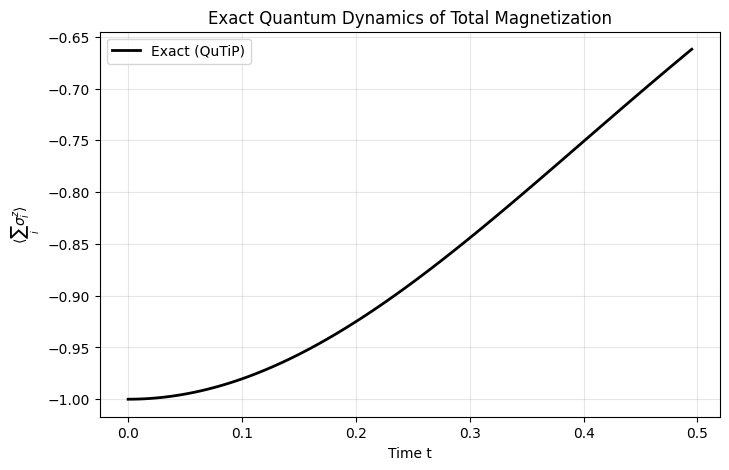

Initial magnetization: -1.000000
Final magnetization: -0.662030


In [5]:
# Time evolution parameters
T = 0.5
J = 1.0
h = 1.0
times_exact = np.linspace(0.0, T, 100)
N = 32

times_exact, magnetizations_exact = get_ed(J,h,N,T)
magnetizations_exact = magnetizations_exact / N
# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

In [6]:

def fit_bridge(n_samples_tvmc, q1, q2, correlation):
    T = 0.5
    save_times = np.linspace(0.0, T, 50)
    exp_name = f"bridge_{n_samples_tvmc}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc, correlation)
    print("num of parameters:", vstate.n_parameters)
    print(vstate.expect(sigma_zs))
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)
    # integrator = RK45(1e-5, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    integrator = Heun(1e-3)
    tvmc_kwargs = {}
    driver = TDVPSchmittRandomizedBlur(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q1=q1,
        q2=q2,
        # flip_prob = 0.1,
        holomorphic=False,
        snr_atol=2.0,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)



In [7]:
for q1, q2 in [
               (0.2, 0.2), 
               (0.2, 1e-10),
               (1e-10, 1e-10),
               ]:
    for correlation in [1.0, 0.0]:
        fit_bridge(2**12, q1=q1, q2=q2, correlation=correlation)

Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...


./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.00_q2_0.00_T_0.50_alpha_1_correlation_0.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.20_T_0.50_alpha_1_correlation_0.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.00_T_0.50_alpha_1_correlation_0.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.00_q2_0.00_T_0.50_alpha_1_correlation_1.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.20_T_0.50_alpha_1_correlation_1.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.00_T_0.50_alpha_1_correlation_1.00/
Restored:


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


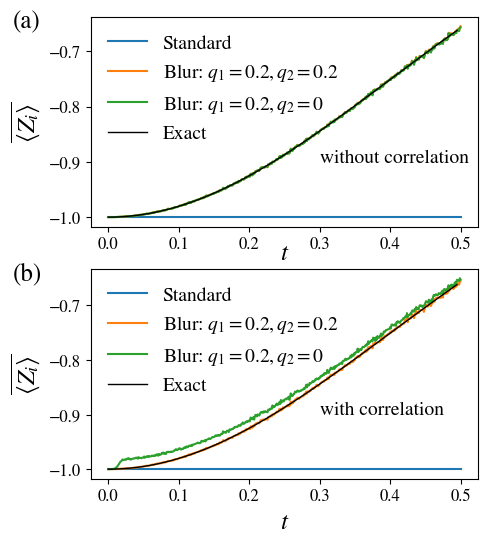

In [8]:

import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

fig, axes = plt.subplots(2, 1, figsize=(5, 6))
ax_1, ax_2 = axes
N = 32
T = 0.5
alpha = 1
correlation = 0.0
for q1, q2 in [(0.0,0.0),
               (0.2, 0.2), 
               (0.2, 0.0),
               ]:
    for n_samples in [2**12]:
        exp_name = f"bridge_{n_samples}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
        save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
        print(save_path)
        logger = Logger(path=save_path, fields=fields_to_track)
        if q1 == 0.0 and q2 == 0.0:
            label = f"Standard"
        elif q2 == 0.0:
            label = rf"Blur: $q_1={q1}, q_2=0$"
        else:
            label = rf"Blur: $q_1={q1}, q_2={q2}$"
        if logger.restore():
            print("Restored:")
            ax_1.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = label, zorder=-1)
ax_1.set_xlabel("t")
ax_1.plot(times_exact[times_exact<0.5], np.real(magnetizations_exact)[times_exact<0.5], 'k-', linewidth=1, label='Exact')


correlation = 1.0

for q1, q2 in [(0.0,0.0),
               (0.2, 0.2), 
               (0.2, 0.0),
               ]:
    for n_samples in [2**12]:
        exp_name = f"bridge_{n_samples}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
        save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
        print(save_path)
        logger = Logger(path=save_path, fields=fields_to_track)
        if q1 == 0.0 and q2 == 0.0:
            label = f"Standard"
        elif q2 == 0.0:
            label = rf"Blur: $q_1={q1}, q_2=0$"
        else:
            label = rf"Blur: $q_1={q1}, q_2={q2}$"
        if logger.restore():
            print("Restored:")
            ax_2.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = label, zorder=-1)
ax_2.plot(times_exact[times_exact<0.5], np.real(magnetizations_exact)[times_exact<0.5], 'k-', linewidth=1, label='Exact')


ax_1.legend(frameon = False, fontsize = 14)
ax_2.legend(frameon = False, fontsize = 14)
ax_2.set_xlabel(r"$t$", fontsize = 18)
ax_1.set_xlabel(r"$t$", fontsize = 18, labelpad=-8)

ax_1.text(0.3, -0.9, "without correlation", fontsize = 14)

ax_2.text(0.3, -0.9, "with correlation", fontsize = 14)

ax_1.set_ylabel(r"$\overline{\langle Z_i \rangle}$",fontsize = 18)
ax_2.set_ylabel(r"$\overline{\langle Z_i \rangle}$",fontsize = 18)

loc_x = -0.2
loc_y = 0.95
ax_1.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=18)
ax_2.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=18)
ax_1.tick_params(axis='both', which='major', labelsize=12)
ax_2.tick_params(axis='both', which='major', labelsize=12)
plt.savefig("Fig6.pdf", bbox_inches="tight", pad_inches=0.01)

In [13]:
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import netket.stats as stats
from netket.optimizer.qgt.qgt_jacobian import QGTJacobian_DefaultConstructor
from netket.utils.api_utils import partial_from_kwargs
from netket.utils import timing, HashablePartial

from tdvp_utils import randomized_blurred_sample
from jax.sharding import PartitionSpec as P

import tqdm


@timing.timed
@partial(
    jax.jit,
    static_argnames=(
        "n_samples",
        "rcond",
        "rcond_smooth",
        "snr_atol",
    ),
)
def _impl(
    n_samples,
    E_loc,
    S,
    importance_weights,
    rcond,
    rcond_smooth,
    snr_atol,
):
    E = stats.statistics(importance_weights * E_loc)
    ΔE_loc = E_loc.reshape(-1, 1) - E.mean

    stack_jacobian = S.mode == "complex"

    O = S.O
    if stack_jacobian:
        O = O.reshape(-1, 2, S.O.shape[-1])
        O = O[:, 0, :] + 1j * O[:, 1, :]
    O = O * jnp.sqrt(
        importance_weights / importance_weights.shape[0]
    )  # Undo PDF since it's already in ΔE_loc
    Sd = S.to_dense()
    ev, V = jnp.linalg.eigh(Sd)

    OEdata = O.conj() * ΔE_loc
    # SNR of the force estimator F = sum_i O_i^* ΔE_i
    OE_mean = stats.mean(OEdata, axis=0)
    OE_var = stats.var(OEdata, axis=0)
    eps = jnp.finfo(O.dtype).eps
    snr_F = jnp.where(
        OE_var <= eps,
        jnp.inf,
        jnp.abs(OE_mean) * jnp.sqrt(n_samples) / jnp.sqrt(OE_var + eps),
    )
    F = stats.sum(OEdata, axis=0)
    # eigenbasis
    Q = jnp.tensordot(V.conj().T, O.T, axes=1).T
    QEdata = Q.conj() * ΔE_loc
    rho = V.conj().T @ F

    # Compute the SNR according to Eq. 21 but taking care of where sigma_k is zero
    sigma_k = jnp.maximum(jnp.sqrt(stats.var(QEdata, axis=0)), rcond)
    # Here we are hardcoding the case where rho==0 and sigma_k==0 to have infinite snr.
    # This is an arbitrary choice, but avoids generating NaNs in the snr calculation.
    # See netket#1959 and #1960 for more details.
    snr = jnp.where(
        sigma_k <= eps,
        jnp.inf,
        jnp.abs(rho) * jnp.sqrt(n_samples) / sigma_k,
    )

    # Discard eigenvalues below numerical precision
    ev_inv = jnp.where(jnp.abs(ev / ev[-1]) > rcond, 1.0 / ev, 0.0)
    # Set regularizer for singular value cutoff
    regularizer = 1.0 / (1.0 + (rcond_smooth / jnp.abs(ev / ev[-1])) ** 6)
    if snr_atol is not None:
        # Construct a soft cutoff based on the SNR
        regularizer = regularizer * (1.0 / (1.0 + (snr_atol / snr) ** 6))

    ev_reg = jnp.where(
        ev_inv * regularizer < 1.0 / rcond, 1.0 / (ev_inv * regularizer), jnp.nan
    )

    return Sd, F, snr, snr_F, V, ev, ev_reg


def get_data(state, q1, q2, flip_prob, w, generator):  # noqa: F811
    # pylint: disable=protected-access

    state.parameters = w
    state.reset()
    chunk_size = getattr(state, "chunk_size", None)

    # Generator and schedules
    op_t = generator
    samples = state.samples
    # Bridge kernel
    state._sampler_seed, key = jax.random.split(state._sampler_seed, 2)

    samples_q, importance_weights, E_loc = HashablePartial(
        randomized_blurred_sample,
        apply_fn=state._apply_fun,
        op=op_t,
        q1=q1,
        q2=q2,
        flip_prob=flip_prob,
        chunk_size=chunk_size,
    )(samples, key, w)
    # print("ESS", ess, "q", self.q)
    # Normalize weights for use as a pdf
    importance_weights = importance_weights / jnp.mean(importance_weights)

    # Get S-matrix
    importance_weights = importance_weights.reshape(samples_q.shape[:-1])
    _S = partial_from_kwargs(
        QGTJacobian_DefaultConstructor,
        exclusive_arg_names=(("mode", "holomorphic")),
    )(
        state._apply_fun,
        state.parameters,
        state.model_state,
        samples_q,
        pdf=importance_weights / importance_weights.size,
        dense=True,
        diag_shift=None,
        diag_scale=None,
        holomorphic=False,
        chunk_size=chunk_size,
    )

    return _impl(state.n_samples, E_loc, _S, importance_weights, 1e-14, 1e-10, 2.0)


def get_qgt(n_samples_tvmc, q1, q2, correlation):
    T = 0.5
    N = 32
    exp_name = f"bridge_{n_samples_tvmc}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    cache_path = f"./data/TFIM_EPS_{N}/{exp_name}/QGT/"
    logger = Logger(path=save_path, fields=fields_to_track)
    vstate = get_vstate(n_samples_tvmc, correlation=correlation)
    qgts = []
    graph = nk.graph.Chain(N, pbc=True)
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1.0, J=-1.0)
    if logger.restore():
        os.makedirs(cache_path, exist_ok=True)
        for i in tqdm.tqdm(range(50)):
            cache_file = os.path.join(cache_path, f"step_{i}.npz")
            if os.path.exists(cache_file):
                data = np.load(cache_file, allow_pickle=False)
                Sd, F, snr, snr_F, V, ev, ev_reg = (
                    data["Sd"],
                    data["F"],
                    data["snr"],
                    data["snr_F"],
                    data["V"],
                    data["ev"],
                    data["ev_reg"],
                )
            else:
                assert logger.restore_state(vstate, var_name=f"_{i}")
                # Thermalize
                for i in range(100):
                    vstate.sample()
                Sd, F, snr, snr_F, V, ev, ev_reg = get_data(
                    state=vstate,
                    q1=q1,
                    q2=q2,
                    flip_prob=0.1,
                    w=vstate.parameters,
                    generator=hamiltonian,
                )
                np.savez(
                    cache_file,
                    Sd=np.array(Sd),
                    F=np.array(F),
                    snr=np.array(snr),
                    snr_F=np.array(snr_F),
                    V=np.array(V),
                    ev=np.array(ev),
                    ev_reg=np.array(ev_reg),
                )
            qgts.append((Sd, F, snr, snr_F, ev, ev_reg))
        return True, qgts
    else:
        return False, None

data = {}
for q1, q2 in [
    (0.2, 0.2),
    (0.2, 1e-10),
    (1e-10, 1e-10),
]:
    for correlation in [1.0, 0.0]:
        success, qgts = get_qgt(2**12, q1=q1, q2=q2, correlation=correlation)
        data[f"q1_{q1:.2f}_q2_{q2:.2f}_correlation_{correlation:.2f}"] = qgts

100%|██████████| 50/50 [00:00<00:00, 768.56it/s]


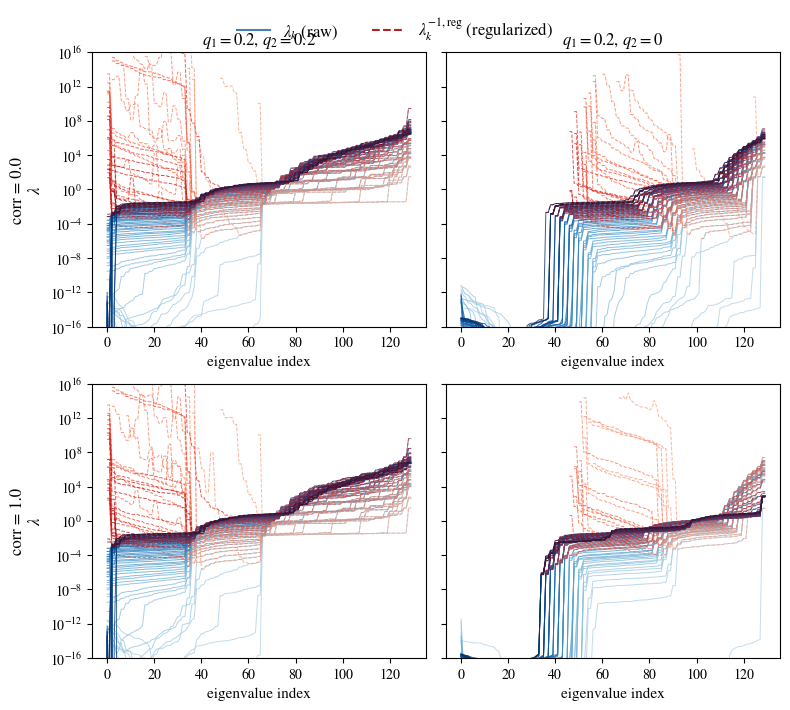

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

q_pairs = [(0.2, 0.2), (0.2, 1e-10), ]
correlations = [0.0, 1.0]
col_labels = [r"$q_1=0.2,\, q_2=0.2$", r"$q_1=0.2,\, q_2=0$", r"$q_1=0,\, q_2=0$"]
row_labels = [f"corr = {c:.1f}" for c in correlations]

fig, axes = plt.subplots(2, 2, figsize=(8, 7), sharey=True, sharex=False)

for row, correlation in enumerate(correlations):
    for col, (q1, q2) in enumerate(q_pairs):
        ax = axes[row, col]
        key = f"q1_{q1:.2f}_q2_{q2:.2f}_correlation_{correlation:.2f}"
        qgts_list = data.get(key)
        if not qgts_list:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        n_steps = len(qgts_list)
        blues = cm.Blues(np.linspace(0.3, 1.0, n_steps))
        reds = cm.Reds(np.linspace(0.3, 1.0, n_steps))

        for step_idx, (Sd, F, snr, snr_F, ev, ev_reg) in enumerate(qgts_list):
            ev_arr = np.abs(np.array(ev))
            ev_reg_arr = np.array(ev_reg)  # contains NaN for filtered eigenvalues
            x = np.arange(len(ev_arr))
            ax.plot(x, ev_arr, color=blues[step_idx], linestyle='-', linewidth=0.7, alpha=0.8)
            ax.plot(x, ev_reg_arr, color=reds[step_idx], linestyle='--', linewidth=0.7, alpha=0.8)

        ax.set_yscale('log')
        ax.set_ylim(1e-16, 1e16)
        ax.set_xlabel("eigenvalue index", fontsize=11)
        if col == 0:
            ax.set_ylabel(row_labels[row] + "\n" + r"$\lambda$", fontsize=12)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=10)

# Shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', linestyle='-',  linewidth=1.5, label=r'$\lambda_k$ (raw)'),
    Line2D([0], [0], color='firebrick',  linestyle='--', linewidth=1.5, label=r'$\lambda_k^{-1,\mathrm{reg}}$ (regularized)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout()
plt.show()


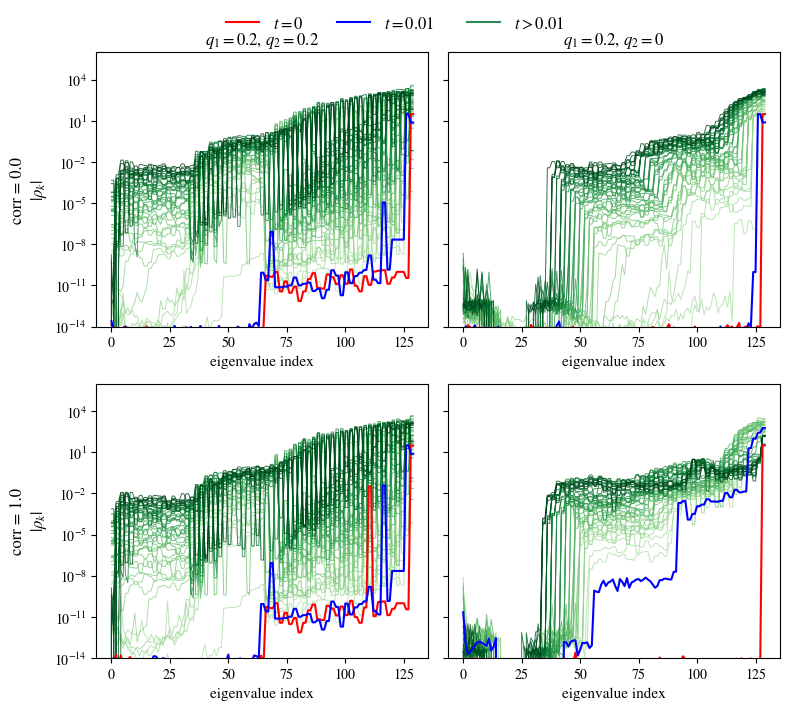

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

q_pairs = [(0.2, 0.2), (0.2, 1e-10), ]
correlations = [0.0, 1.0]
col_labels = [r"$q_1=0.2,\, q_2=0.2$", r"$q_1=0.2,\, q_2=0$", r"$q_1=0,\, q_2=0$"]
row_labels = [f"corr = {c:.1f}" for c in correlations]

N_plot = 32
T_plot = 0.5
n_samples_tvmc = 2**12
alpha=1
fig, axes = plt.subplots(2, 2, figsize=(8, 7), sharey=True, sharex=False)

HIGHLIGHT_COLORS = ['red', 'blue']

for row, correlation in enumerate(correlations):
    for col, (q1, q2) in enumerate(q_pairs):
        ax = axes[row, col]
        exp_name = f"bridge_{n_samples_tvmc}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T_plot:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
        cache_path = f"./data/TFIM_EPS_{N_plot}/{exp_name}/QGT/"

        rho_list = []
        for i in range(50):
            cache_file = os.path.join(cache_path, f"step_{i}.npz")
            d = np.load(cache_file, allow_pickle=False)
            F_i = d["F"]        # shape (n_params,)
            V_i = d["V"]        # shape (n_params, n_params), columns are eigenvectors
            rho_i = V_i.conj().T @ F_i   # project F into eigenbasis of S
            rho_list.append(np.abs(rho_i))

        n_steps = len(rho_list)
        greens = cm.Greens(np.linspace(0.3, 1.0, n_steps))

        for step_idx, rho_abs in enumerate(rho_list):
            x = np.arange(len(rho_abs))
            if step_idx < len(HIGHLIGHT_COLORS):
                color = HIGHLIGHT_COLORS[step_idx]
                lw, alpha_val, zorder = 1.5, 1.0, 5
            else:
                color = greens[step_idx]
                lw, alpha_val, zorder = 0.7, 0.8, 1
            ax.plot(x, rho_abs, color=color, linestyle='-', linewidth=lw, alpha=alpha_val, zorder=zorder)

        ax.set_yscale('log')
        ax.set_ylim(1e-14, 1e)
        ax.set_xlabel("eigenvalue index", fontsize=11)
        if col == 0:
            ax.set_ylabel(row_labels[row] + "\n" + r"$|\rho_k|$", fontsize=12)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=10)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red',      linestyle='-', linewidth=1.5, label=r'$t=0$'),
    Line2D([0], [0], color='blue',     linestyle='-', linewidth=1.5, label=r'$t=0.01$'),
    Line2D([0], [0], color='seagreen', linestyle='-', linewidth=1.5, label=r'$t>0.01$'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout()
plt.show()


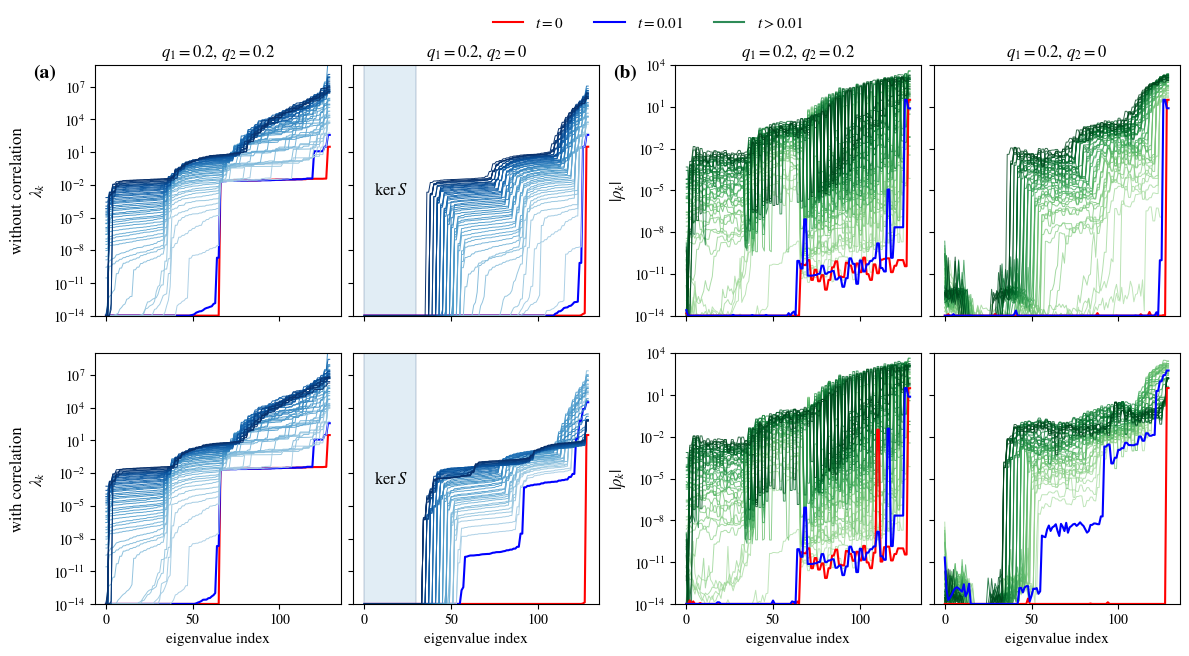

In [65]:

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.lines import Line2D

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

q_pairs = [(0.2, 0.2), (0.2, 1e-10)]
correlations = [0.0, 1.0]
col_labels_ev  = [r"$q_1=0.2,\, q_2=0.2$",  r"$q_1=0.2,\, q_2=0$"]
col_labels_rho = [r"$q_1=0.2,\, q_2=0.2$",  r"$q_1=0.2,\, q_2=0$"]
row_labels = [r"without correlation", r"with correlation"]

N_plot       = 32
T_plot       = 0.5
n_samples_tvmc = 2**12
alpha_val_run = 1

HIGHLIGHT_COLORS = ['red', 'blue']

# ── nested GridSpec: outer separates the two subblocks (large wspace),
#    inner pairs each subblock's columns tightly (small wspace) ──────────
fig = plt.figure(figsize=(14, 7))
outer_gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.15)

inner_gs_ev  = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[0], wspace=0.05, hspace=0.15)
inner_gs_rho = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[1], wspace=0.05, hspace=0.15)

# Build axes[row, col] array matching previous layout conventions
axes = np.empty((2, 4), dtype=object)
for row in range(2):
    for col in range(2):
        axes[row, col]     = fig.add_subplot(inner_gs_ev[row, col])
        axes[row, col + 2] = fig.add_subplot(inner_gs_rho[row, col])

# Share y-axes within each subblock
for row in range(2):
    axes[row, 1].sharey(axes[row, 0])
    axes[row, 3].sharey(axes[row, 2])

for row, correlation in enumerate(correlations):
    for col, (q1, q2) in enumerate(q_pairs):

        # ── left subblock: eigenvalues ──────────────────────────────────
        ax_ev = axes[row, col]
        key = f"q1_{q1:.2f}_q2_{q2:.2f}_correlation_{correlation:.2f}"
        qgts_list = data.get(key)
        if not qgts_list:
            ax_ev.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_ev.transAxes)
        else:
            n_steps = len(qgts_list)
            blues = cm.Blues(np.linspace(0.3, 1.0, n_steps))
            reds  = cm.Reds( np.linspace(0.3, 1.0, n_steps))
            for step_idx, (Sd, F, snr, snr_F, ev, ev_reg) in enumerate(qgts_list):
                ev_arr     = np.array(ev)
                x = np.arange(len(ev_arr))
                if step_idx < len(HIGHLIGHT_COLORS):
                    c, lw, a, zo = HIGHLIGHT_COLORS[step_idx], 1.5, 1.0, 5
                else:
                    c, lw, a, zo = blues[step_idx], 0.7, 0.8, 1
                ax_ev.plot(x, np.clip(ev_arr, 1e-14,1e16), color=c, linestyle='-', linewidth=lw, alpha=alpha)

        if col == 1:
            ax_ev.axvspan(0, 30, facecolor=blues[25], alpha=0.15,
                          edgecolor=blues[-1], linewidth=1.2, zorder=0)
            # Label in the geometric centre of the rectangle (log-scale y mid)
            ax_ev.text(15, 10**(-14/2 + 9/2), r"$\ker S$",
                       ha='center', va='center', fontsize=12,
                       color='black', zorder=1)
        ax_ev.set_yscale('log')
        ax_ev.set_ylim(1e-14, 1e9)
        if row == 1:
            ax_ev.set_xlabel("eigenvalue index", fontsize=11)
        if col == 0:
            ylabel = row_labels[row] + "\n" + r"$\lambda_k$"
            ax_ev.set_ylabel(ylabel, fontsize=12)
        if row == 0:
            ax_ev.set_title(col_labels_ev[col], fontsize=12)
            plt.setp(ax_ev.get_xticklabels(), visible=False)
        if col == 1:
            plt.setp(ax_ev.get_yticklabels(), visible=False)
        ax_ev.tick_params(axis='both', which='major', labelsize=10)

        # ── right subblock: projected force |ρ_k| ──────────────────────
        ax_rho = axes[row, col + 2]
        exp_name   = (f"bridge_{n_samples_tvmc}_rbm_q1_{q1:.2f}_q2_{q2:.2f}"
                      f"_T_{T_plot:.2f}_alpha_{alpha_val_run}_correlation_{correlation:.2f}")
        cache_path = f"./data/TFIM_EPS_{N_plot}/{exp_name}/QGT/"

        rho_list = []
        for i in range(50):
            cache_file = os.path.join(cache_path, f"step_{i}.npz")
            d = np.load(cache_file, allow_pickle=False)
            rho_i = d["V"].conj().T @ d["F"]
            rho_list.append(np.abs(rho_i))

        n_steps = len(rho_list)
        greens  = cm.Greens(np.linspace(0.3, 1.0, n_steps))

        for step_idx, rho_abs in enumerate(rho_list):
            x = np.arange(len(rho_abs))
            if step_idx < len(HIGHLIGHT_COLORS):
                c, lw, a, zo = HIGHLIGHT_COLORS[step_idx], 1.5, 1.0, 5
            else:
                c, lw, a, zo = greens[step_idx], 0.7, 0.8, 1
            ax_rho.plot(x, np.clip(rho_abs, 1e-14,1e16), color=c, linestyle='-', linewidth=lw, alpha=a, zorder=zo)

        ax_rho.set_yscale('log')
        ax_rho.set_ylim(1e-14, 1e4)
        if row == 1:
            ax_rho.set_xlabel("eigenvalue index", fontsize=11)
        if col == 0:
            ylabel = r"$|\rho_k|$"
            ax_rho.set_ylabel(ylabel, fontsize=12)
        if row == 0:
            ax_rho.set_title(col_labels_rho[col], fontsize=12)
            plt.setp(ax_rho.get_xticklabels(), visible=False)
        if col == 1:
            plt.setp(ax_rho.get_yticklabels(), visible=False)
        ax_rho.tick_params(axis='both', which='major', labelsize=10)

# # ── column-block headers ────────────────────────────────────────────────
# for ax, label in zip([axes[0, 0], axes[0, 2]], [r"Eigenvalues $\lambda_k$", r"Projected force $|\rho_k|$"]):
#     ax.annotate(label, xy=(1.0, 1.12), xycoords='axes fraction',
#                 ha='center', fontsize=13, fontweight='bold')

# ── panel labels ────────────────────────────────────────────────────────
axes[0, 0].annotate("(a)", xy=(-0.25, 0.95), xycoords='axes fraction',
                    fontsize=14, fontweight='bold')
axes[0, 2].annotate("(b)", xy=(-0.25, 0.95), xycoords='axes fraction',
                    fontsize=14, fontweight='bold')

# ── shared legend ───────────────────────────────────────────────────────
rho_legend = [
    Line2D([0], [0], color='red',      linestyle='-', linewidth=1.5, label=r'$t=0$'),
    Line2D([0], [0], color='blue',     linestyle='-', linewidth=1.5, label=r'$t=0.01$'),
    Line2D([0], [0], color='seagreen', linestyle='-', linewidth=1.5, label=r'$t>0.01$'),
]
fig.legend(handles=rho_legend, loc='upper center', bbox_to_anchor=(0.52, 0.97), ncol=3, fontsize=11, frameon=False)

plt.savefig("Fig6_qgt.pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()
